# Autocall Athena — Neural Network Proxy Pricing Model

Pricing a structured product via Monte Carlo takes ~100ms per computation.
This project trains a neural network to replicate the pricer — 
same accuracy, 3,000x faster.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

def pricer_autocall(S0, sigma, r, T, barriere_absolue, coupon, n_simulations=10_000):
    """
    Monte Carlo pricer for an Autocall Athena.
    
    Parameters:
        S0               : initial spot price (e.g. 100)
        sigma            : annualized volatility (e.g. 0.20 for 20%)
        r                : risk-free rate (e.g. 0.03 for 3%)
        T                : maturity in years (e.g. 3)
        barriere_absolue : absolute recall barrier in euros (e.g. 100.0)
        coupon           : annual coupon if recalled (e.g. 0.08 for 8%)
    """
    dt    = 1/252
    n_steps = int(T * 252)
    observation_dates = [int(i * 252) for i in range(1, T + 1)]

    # Geometric Brownian Motion simulation
    Z            = np.random.normal(0, 1, (n_simulations, n_steps))
    returns      = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    trajectories = S0 * np.exp(np.cumsum(returns, axis=1))

    payoffs = np.zeros(n_simulations)

    for i in range(n_simulations):
        redeemed = False
        for t in observation_dates:
            St   = trajectories[i, t - 1]
            year = t // 252
            # Absolute barrier — does NOT move when S0 moves
            if St >= barriere_absolue:
                payoffs[i] = (1 + coupon * year)
                redeemed   = True
                break
        if not redeemed:
            payoffs[i] = 1.0  # capital returned at maturity

    return np.mean(payoffs) * np.exp(-r * T)

# Sanity check
price_test = pricer_autocall(S0=100, sigma=0.20, r=0.03, T=3,
                              barriere_absolue=100.0, coupon=0.08)
print(f"Autocall price (Monte Carlo): {price_test:.4f}")

Autocall price (Monte Carlo): 0.9852


## Step 1 — Monte Carlo Dataset

We simulate 5,000 market scenarios (varying spot, vol, rate, maturity, coupon)
and compute the Autocall price for each one using Monte Carlo (GBM).
This is the training data for the neural network.

In [2]:
n_samples = 5_000
np.random.seed(42)

data = {
    "S0"      : np.random.uniform(75, 125, n_samples),
    "sigma"   : np.random.uniform(0.10, 0.40, n_samples),
    "r"       : np.random.uniform(0.01, 0.05, n_samples),
    "T"       : np.random.randint(1, 4, n_samples).astype(float),
    "barriere": np.full(n_samples, 100.0),   # fixed absolute barrier
    "coupon"  : np.random.uniform(0.05, 0.12, n_samples),
}

df = pd.DataFrame(data)
df["moneyness"] = df["S0"] / df["barriere"]   # spot / barrier ratio

print("Computing Monte Carlo prices...")
prix_mc = []

for i, row in df.iterrows():
    p = pricer_autocall(
        S0=row["S0"], sigma=row["sigma"], r=row["r"],
        T=int(row["T"]), barriere_absolue=row["barriere"],
        coupon=row["coupon"], n_simulations=5_000
    )
    prix_mc.append(p)
    if i % 500 == 0:
        print(f"  {i}/{n_samples} computed...")

df["prix_mc"] = prix_mc
df.to_csv("dataset_autocall.csv", index=False)
print(f"Dataset saved: {len(df)} rows")
print(df[["S0", "moneyness", "prix_mc"]].describe())

Computing Monte Carlo prices...
  0/5000 computed...
  500/5000 computed...
  1000/5000 computed...
  1500/5000 computed...
  2000/5000 computed...
  2500/5000 computed...
  3000/5000 computed...
  3500/5000 computed...
  4000/5000 computed...
  4500/5000 computed...
Dataset saved: 5000 rows
                S0    moneyness      prix_mc
count  5000.000000  5000.000000  5000.000000
mean     99.841600     0.998416     0.997559
std      14.481683     0.144817     0.032976
min      75.000582     0.750006     0.903302
25%      87.193140     0.871931     0.975777
50%     100.000431     1.000004     0.998873
75%     112.405043     1.124050     1.020381
max     124.985884     1.249859     1.089259


## Step 2 — Proxy Model Training

A 4-layer MLP (6,721 parameters) learns to replicate the pricing function.
Train/test split: 80% / 20%. Inputs and output are standardized.

In [3]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("dataset_autocall.csv")

features = ["S0", "sigma", "r", "T", "barriere", "coupon", "moneyness"]
X = df[features].values
y = df["prix_mc"].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s  = scaler_y.transform(y_test)

X_train_t = torch.FloatTensor(X_train_s)
y_train_t = torch.FloatTensor(y_train_s)
X_test_t  = torch.FloatTensor(X_test_s)
y_test_t  = torch.FloatTensor(y_test_s)

class PricerNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(7, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

model     = PricerNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=300, gamma=0.5)
loss_fn   = nn.MSELoss()

for epoch in range(1000):
    model.train()
    y_pred = model(X_train_t)
    loss   = loss_fn(y_pred, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

print("Training complete.")

Epoch    0 | Loss: 1.023857
Epoch  200 | Loss: 0.004490
Epoch  400 | Loss: 0.002490
Epoch  600 | Loss: 0.001871
Epoch  800 | Loss: 0.001654
Training complete.


## Step 3 — Results

Model evaluated on 1,000 out-of-sample prices never seen during training.

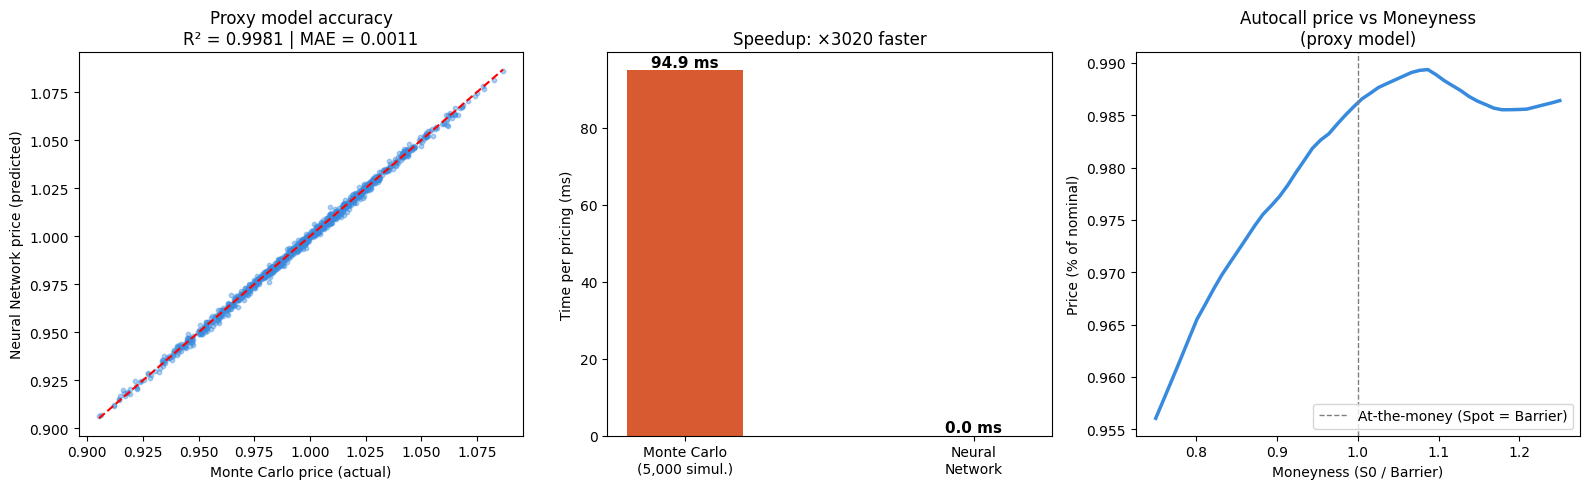

R²              = 0.9981
MAE             = 0.0011  (0.11% of nominal)
Monte Carlo     = 94.9 ms
Neural Network  = 0.031 ms
Speedup         = ×3020


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import time

# Out-of-sample accuracy
model.eval()
with torch.no_grad():
    y_pred_s = model(X_test_t).numpy()

y_pred_real = scaler_y.inverse_transform(y_pred_s)
y_test_real = scaler_y.inverse_transform(y_test_s)
r2          = r2_score(y_test_real, y_pred_real)
mae         = np.mean(np.abs(y_pred_real - y_test_real))

# Speedup benchmark
start = time.time()
for _ in range(100):
    pricer_autocall(100, 0.20, 0.03, 3, 100.0, 0.08, n_simulations=5_000)
time_mc = (time.time() - start) / 100

x_single = torch.FloatTensor(
    scaler_X.transform([[100, 0.20, 0.03, 3, 100.0, 0.08, 1.0]])
)
start = time.time()
for _ in range(100):
    with torch.no_grad():
        model(x_single)
time_nn = (time.time() - start) / 100
speedup  = time_mc / time_nn

# Price vs Moneyness curve
moneyness_range = np.linspace(0.75, 1.25, 50)
nn_prices       = []

for m in moneyness_range:
    s0 = m * 100
    x  = scaler_X.transform([[s0, 0.20, 0.03, 3, 100.0, 0.08, m]])
    with torch.no_grad():
        p = model(torch.FloatTensor(x)).item()
    nn_prices.append(scaler_y.inverse_transform([[p]])[0][0])

# Plots 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Accuracy
axes[0].scatter(y_test_real, y_pred_real, alpha=0.4, s=10, color="#378ADD")
axes[0].plot([y_test_real.min(), y_test_real.max()],
             [y_test_real.min(), y_test_real.max()], 'r--', lw=1.5)
axes[0].set_xlabel("Monte Carlo price (actual)")
axes[0].set_ylabel("Neural Network price (predicted)")
axes[0].set_title(f"Proxy model accuracy\nR² = {r2:.4f} | MAE = {mae:.4f}")

# Plot 2 — Speedup
axes[1].bar(["Monte Carlo\n(5,000 simul.)", "Neural\nNetwork"],
            [time_mc * 1000, time_nn * 1000],
            color=["#D85A30", "#1D9E75"], width=0.4)
axes[1].set_ylabel("Time per pricing (ms)")
axes[1].set_title(f"Speedup: ×{speedup:.0f} faster")
for i, v in enumerate([time_mc * 1000, time_nn * 1000]):
    axes[1].text(i, v + 1, f"{v:.1f} ms", ha='center',
                 fontsize=11, fontweight='bold')

# Plot 3 — Price vs Moneyness
axes[2].plot(moneyness_range, nn_prices, color="#378ADD", lw=2.5)
axes[2].axvline(x=1.0, color='gray', linestyle='--', lw=1,
                label='At-the-money (Spot = Barrier)')
axes[2].set_xlabel("Moneyness (S0 / Barrier)")
axes[2].set_ylabel("Price (% of nominal)")
axes[2].set_title("Autocall price vs Moneyness\n(proxy model)")
axes[2].legend()

plt.tight_layout()
plt.savefig("resultats_finaux.png", dpi=150)
plt.show()

print(f"R²              = {r2:.4f}")
print(f"MAE             = {mae:.4f}  ({mae*100:.2f}% of nominal)")
print(f"Monte Carlo     = {time_mc*1000:.1f} ms")
print(f"Neural Network  = {time_nn*1000:.3f} ms")
print(f"Speedup         = ×{speedup:.0f}")